In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.svm import SVC
from sklearn import metrics
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_absolute_error as mse

import warnings
warnings.filterwarnings('ignore')

In [86]:
df=pd.read_csv("Inventory Demand Forecasting.csv")

In [87]:
df.head(5)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [89]:
df.shape

(913000, 4)

In [90]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [91]:
parts= df["date"].str.split("-",n=3,expand=True)
df["Year"]=parts[0].astype('int')
df["Month"]= parts[1].astype('int')
df["Day"]= parts[2].astype('int')
df.head(5)

,date,store,item,sales,Year,Month,Day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


In [92]:
from datetime import datetime
def weekend_or_weekday(Year,Month,Day):
    d=datetime(Year,Month,Day)
    return 1 if d.weekday() > 4 else 0

df["Weekend"]= df.apply(lambda x: weekend_or_weekday(x['Year'],x['Month'],x['Day']),axis=1)


In [93]:
df["Month"].value_counts().sort_index(ascending=True)

Month
1     77500
2     70500
3     77500
4     75000
5     77500
6     75000
7     77500
8     77500
9     75000
10    77500
11    75000
12    77500
Name: count, dtype: int64

In [94]:
df['m1']=np.sin(df['Month']* (2*np.pi/12))
df['m2']=np.cos(df['Month']* (2*np.pi/12))

In [95]:
df['date']=pd.to_datetime(df[['Year','Month','Day']])
df['WeekDay']=df['date'].dt.weekday

In [96]:
df.drop(columns=['date'],axis=1,inplace=True)

In [97]:
df.head(5)

,store,item,sales,Year,Month,Day,Weekend,m1,m2,WeekDay
0,1,1,13,2013,1,1,0,0.5,0.866025,1
1,1,1,11,2013,1,2,0,0.5,0.866025,2
2,1,1,14,2013,1,3,0,0.5,0.866025,3
3,1,1,13,2013,1,4,0,0.5,0.866025,4
4,1,1,10,2013,1,5,1,0.5,0.866025,5


In [98]:
df['item'].nunique(), df['store'].nunique()

(50, 10)

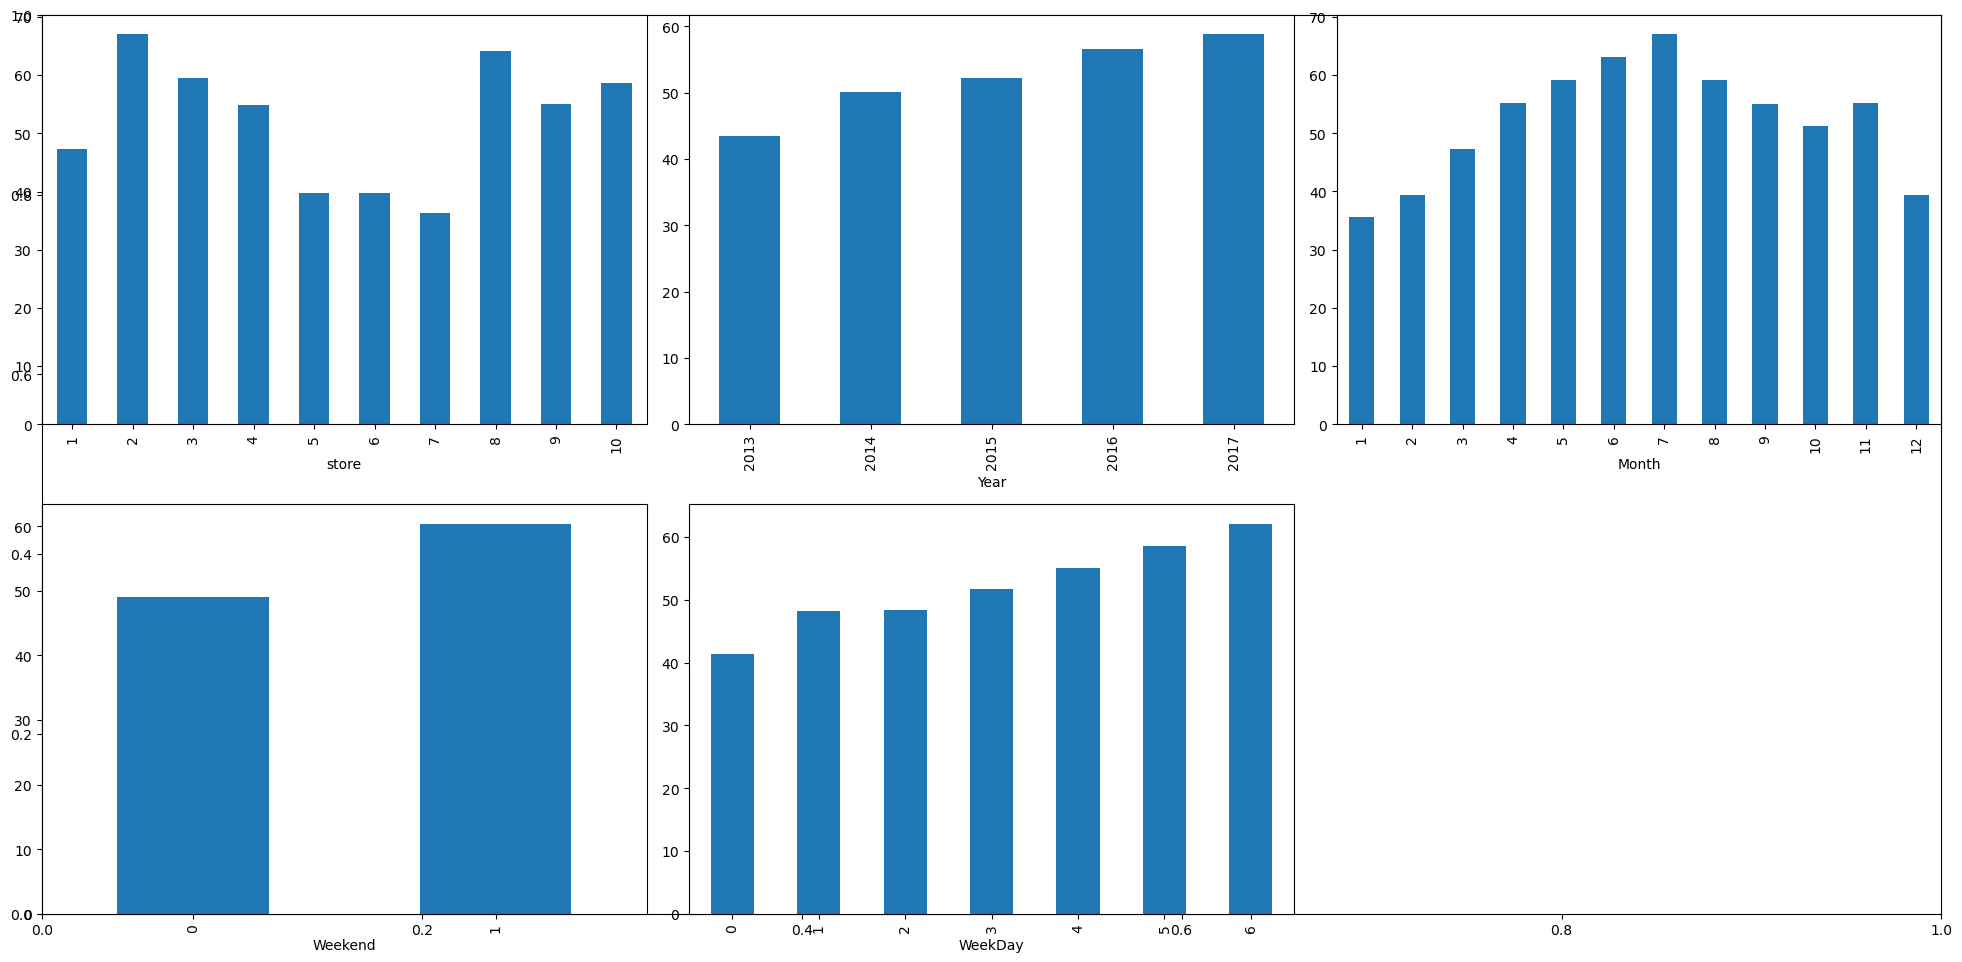

In [99]:
df['Weekend']= df['WeekDay'].apply(lambda x: 1 if x>=5 else 0)
features=['store','Year','Month','Weekend','WeekDay']

plt.subplots(figsize=(20,10))
for i ,col in enumerate(features):
    plt.subplot(2,3,i+1)
    df.groupby(col).mean()['sales'].plot.bar()
    plt.tight_layout()
plt.show()

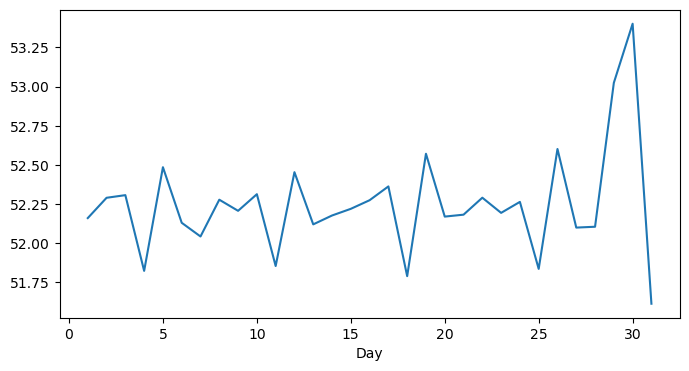

In [100]:
plt.figure(figsize=(8,4))
df.groupby('Day').mean()['sales'].plot()
plt.show()

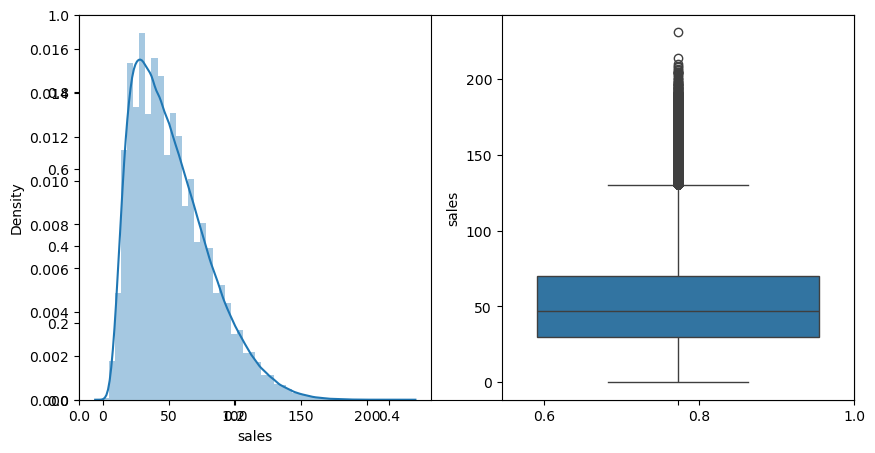

In [101]:
plt.subplots(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(df['sales'])

plt.subplot(1,2,2)
sns.boxplot(df['sales'])
plt.show()

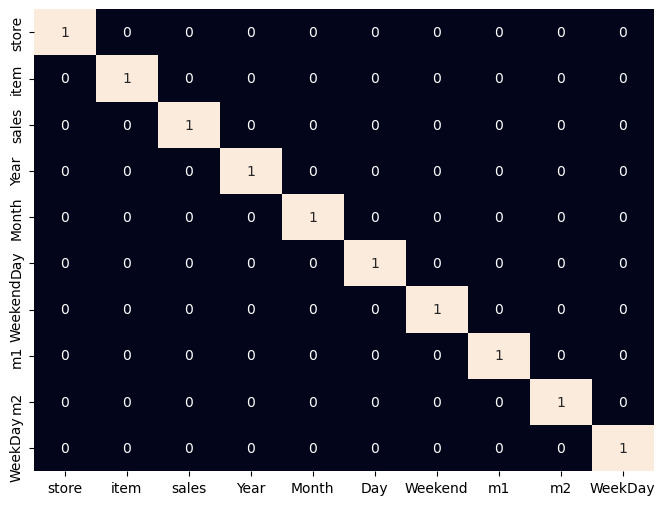

In [102]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr()>0.8,annot=True,cbar=False)
plt.show()

In [103]:
df=df[df['sales']<140]

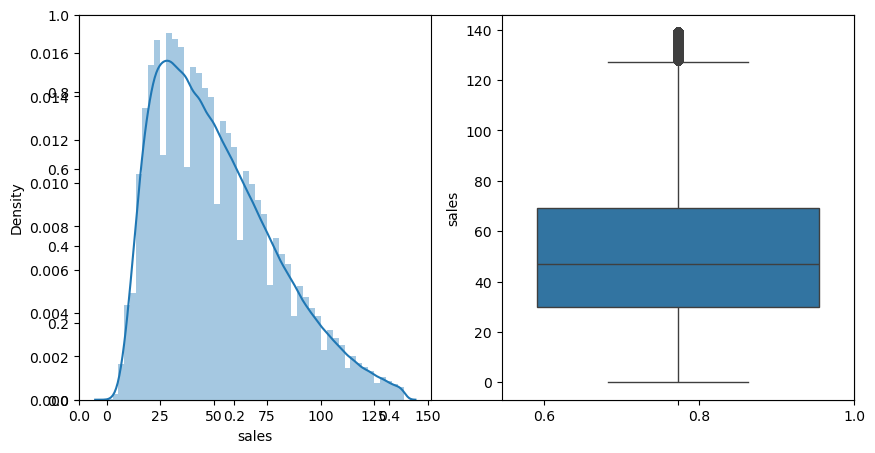

In [104]:
plt.subplots(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(df['sales'])

plt.subplot(1,2,2)
sns.boxplot(df['sales'])
plt.show()

In [105]:
X=df.drop(columns=["sales","Year"],axis=1)
y=df["sales"]

In [106]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
X_train.shape, X_test.shape

((725196, 8), (181299, 8))

In [111]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit & transform on train
X_test_scaled = scaler.transform(X_test)

In [112]:
models = [LinearRegression(), XGBRegressor(), Ridge(), Lasso()]

# Train & evaluate
for model in models:
    model.fit(X_train_scaled, y_train)
    print(f'{model}:')
    
    # Training predictions
    train_predictions = model.predict(X_train_scaled)
    print('Training Error:', mse(y_train, train_predictions))
    
    # Test predictions
    test_predictions = model.predict(X_test_scaled)
    print('Validation Error:', mse(y_test, test_predictions))
    print()


LinearRegression():
Training Error: 20.915841514570662
Validation Error: 20.862959565902404

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...):
Training Error: 6.910688400268555
Validation Error: 6.964951515197754

Ridge():
Training Error: 20.915841674861426
Validation Error: 20.86295976548258

Lasso():
Training Error: 21.027463653144224
Validation Error: 20.

In [113]:
XGBR=XGBRegressor()

In [116]:
XGBR.fit(X_train_scaled,y_train)

,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,gamma,0


In [117]:
y_pred=XGBR.predict(X_test_scaled)

In [121]:
from sklearn.metrics import mean_squared_error, r2_score

print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test R2:", r2_score(y_test, y_pred))

Test MSE: 82.68423461914062
Test R2: 0.8914374113082886
